# **Loading The Data**

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from skimage import exposure
import pickle
import random
import sys
import gc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
base_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή"

In [4]:
sys.path.append('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή')
from PreProcessing_Script import dataset_preparation, Model

In [5]:
effnet_root_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 Model"

def create_experiment_folders(experiment_name):
    experiment_dir = os.path.join(effnet_root_dir, experiment_name)
    results_dir = os.path.join(experiment_dir, "results")
    images_dir = os.path.join(results_dir, "images")
    models_dir = os.path.join(results_dir, "models")
    report_dir = os.path.join(results_dir, "report")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    return {
        "experiment_dir": experiment_dir,
        "results_dir": results_dir,
        "images_dir": images_dir,
        "models_dir": models_dir,
        "report_dir": report_dir
    }

combined_roc_effnet_path = os.path.join(effnet_root_dir, "combined_roc_effnet.png")
effnet_experiments_path  = os.path.join(effnet_root_dir, "effnet_experiments.pkl")

In [6]:
K = 5
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-4
Class_Names = ["Glioma", "Meningioma", "Pituitary"]
all_experiments = {}
input_shape = (224, 224, 3)

In [7]:
x_train_val_raw = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_train_val_raw.pkl","rb"))
x_test_raw      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_test_raw.pkl","rb"))
y_train_val_int = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_train_val_int.pkl","rb"))
y_test_int      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_test_int.pkl","rb"))

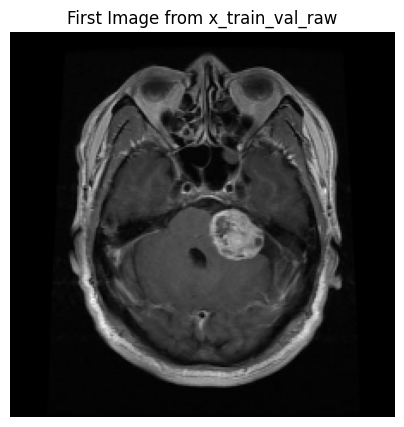

In [8]:
# Select the first image from x_train_val_raw
# Assuming x_train_val_raw is a NumPy array of images
image_to_display = x_train_val_raw[0]

plt.figure(figsize=(5, 5))
plt.imshow(image_to_display, cmap='gray')
plt.title('First Image from x_train_val_raw')
plt.axis('off') # Hide axes ticks and labels
plt.show()

# Saving

In [9]:
def get_save_paths(model_or_experiment_name):
    if isinstance(model_or_experiment_name, str):
        experiment_name = model_or_experiment_name
    else:
        experiment_name = model_or_experiment_name.experiment_name

    folders = create_experiment_folders(experiment_name)

    paths = {
        "model": os.path.join(folders["models_dir"], f"{experiment_name}.keras"),
        "train_loss": os.path.join(folders["images_dir"], f"{experiment_name}_train_loss.png"),
        "train_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_train_accuracy.png"),
        "confusion_matrix": os.path.join(folders["images_dir"], f"{experiment_name}_confusion_matrix.png"),
        "roc_curve": os.path.join(folders["images_dir"], f"{experiment_name}_roc_curve.png"),
        "auc_report": os.path.join(folders["report_dir"], f"{experiment_name}_auc_report.txt"),
        "classification_report": os.path.join(folders["report_dir"], f"{experiment_name}_classification_report.txt"),
        "confusion_matrix_txt": os.path.join(folders["report_dir"], f"{experiment_name}_confusion_matrix.txt"),
        "kfold_metrics": os.path.join(folders["report_dir"], f"{experiment_name}_kfold_metrics.txt"),
        "kfold_loss": os.path.join(folders["images_dir"], f"{experiment_name}_kfold_loss.png"),
        "kfold_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_kfold_accuracy.png"),
        "roc_raw_data": os.path.join(folders["report_dir"], f"{experiment_name}_roc_raw_data")
    }

    return paths

# Plots

In [10]:
def acc_and_loss(history, model_experiment_name, save_paths=None):
  hist = history.history

  epochs_acc = np.arange(1, len(hist["accuracy"])+1)
  epochs_loss = np.arange(1, len(hist["loss"])+1)

  fig_acc, ax_acc = plt.subplots(figsize=(10,5), dpi = 120)
  ax_acc.plot(
      epochs_acc,
      hist["accuracy"],
      label = "Training Accuracy",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_accuracy" in hist:
    ax_acc.plot(
        epochs_acc,
        hist["val_accuracy"],
        label = "Validation Accuracy",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_acc.set_title(f"{model_experiment_name} - Accuracy")
  ax_acc.set_xlabel("Epoch")
  ax_acc.set_ylabel("Accuracy")
  ax_acc.legend()
  ax_acc.grid(alpha=0.3)

  if save_paths is not None:
    fig_acc.savefig(save_paths["train_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

  fig_loss, ax_loss = plt.subplots(figsize=(10,5), dpi = 120)
  ax_loss.plot(
      epochs_loss,
      hist["loss"],
      label = "Training Loss",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_loss" in hist:
    ax_loss.plot(
        epochs_loss,
        hist["val_loss"],
        label = "Validation Loss",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_loss.set_title(f"{model_experiment_name} - Loss")
  ax_loss.set_xlabel("Epoch")
  ax_loss.set_ylabel("Loss")
  ax_loss.legend()
  ax_loss.grid(alpha=0.3)

  if save_paths is not None:
    fig_loss.savefig(save_paths["train_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  print('Loss:')
  print('  - loss [training dataset]: {:.3f}'.format(hist['loss'][-1]))
  if 'val_loss' in hist:
    print('  - loss [validation dataset]: {:.3f}'.format(hist['val_loss'][-1]))

  print('')
  print('Accuracy:')
  print('  - accuracy [training dataset]: {:.2f}%'.format(hist['accuracy'][-1] * 100))
  if 'val_accuracy' in hist:
    print('  - accuracy [validation dataset]: {:.2f}%'.format(hist['val_accuracy'][-1] * 100))

  return fig_acc, fig_loss

In [11]:
def plot_kfold(histories, title_prefix='', save_paths = None):

  min_len = min([len(h['loss']) for h in histories])

  train_loss = np.array([h['loss'][:min_len] for h in histories])
  val_loss = np.array([h['val_loss'][:min_len] for h in histories])

  train_acc = np.array([h['accuracy'][:min_len] for h in histories])
  val_acc = np.array([h['val_accuracy'][:min_len] for h in histories])

  epochs = np.arange(1, min_len+1)

  # Loss plot
  fig_loss, ax_loss = plt.subplots(figsize=(10, 5), dpi=120)
  ax_loss.plot(epochs, train_loss.mean(axis=0), label='Training Loss')
  ax_loss.plot(epochs, val_loss.mean(axis=0), label='Validation Loss')
  ax_loss.set_title(f'{title_prefix} - KFold Loss')
  ax_loss.set_xlabel('Epochs')
  ax_loss.set_ylabel('Loss')
  ax_loss.legend()
  ax_loss.grid(True, alpha=0.3)
  fig_loss.tight_layout()

  if save_paths is not None and "kfold_loss" in save_paths:
    fig_loss.savefig(save_paths["kfold_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  # Accuracy plot
  fig_acc, ax_acc = plt.subplots(figsize=(10, 5), dpi=120)
  ax_acc.plot(epochs, train_acc.mean(axis=0), label='Training Accuracy')
  ax_acc.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy')
  ax_acc.set_title(f'{title_prefix} - KFold Accuracy')
  ax_acc.set_xlabel('Epochs')
  ax_acc.set_ylabel('Accuracy')
  ax_acc.legend()
  ax_acc.grid(True, alpha=0.3)
  fig_acc.tight_layout()

  if save_paths is not None and "kfold_accuracy" in save_paths:
    fig_acc.savefig(save_paths["kfold_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

In [12]:
def plot_confusion_matrix(cm, Class_Names, save_path=None):

  plt.figure()
  plt.colorbar(plt.imshow(cm))
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.xticks(np.arange(len(Class_Names)), Class_Names, rotation=45)
  plt.yticks(np.arange(len(Class_Names)), Class_Names)

  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, str(cm[i, j]), ha="center", va="center")

  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

In [13]:
def plot_roc_auc(y_true_int, y_prob, class_names, save_path=None):
  n_classes = len(class_names)

  y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))

  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  plt.figure(figsize=(10, 10), dpi=120)

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

  plt.plot([0,1], [0,1], 'k--', linewidth=1)

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve (One-vs-Rest)")
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

  macro_auc = np.mean(list(roc_auc.values()))
  print("\nAUC per Class: ")
  for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
  print(f"Macro AUC: {macro_auc:.4f}")

  return roc_auc, macro_auc

In [14]:
def plot_combined_roc(experiments, class_names, save_path=None):
    n_classes = len(class_names)

    plt.figure(figsize=(10, 10), dpi=120)

    for exp_name, exp_data in experiments.items():
        data = np.load(exp_data["roc_raw_data"])

        all_fpr  = np.linspace(0, 1, 100)
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            fpr = data[f"fpr_{i}"]
            tpr = data[f"tpr_{i}"]
            mean_tpr += np.interp(all_fpr, fpr, tpr)

        mean_tpr /= n_classes
        macro_auc = exp_data["macro_auc"]

        plt.plot(all_fpr, mean_tpr, linewidth=2,
                 label=f"{exp_name} (Macro AUC = {macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Macro Average)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

# Compile Function

In [15]:
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
    )
    return model

# EfficientNetB0 Base Models

## Base Model

In [16]:
def effnetb0_frozen(use_augmentation=False, model_key="effnetb0_frozen"):

  base_model = EfficientNetB0(
      weights = "imagenet",
      include_top = False,
      input_shape = (224,224,3)
  )

  base_model.trainable = False

  inputs = layers.Input(shape=(224,224,3))
  x = base_model(inputs, training = False)

  if use_augmentation:
    augmentation = build_augmentation()
    x = augmentation(x)

  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dropout(0.2)(x)
  outputs = layers.Dense(3, activation="softmax")(x)

  model = tf.keras.Model(inputs = inputs, outputs = outputs, name=model_key)

  model.model_key = model_key

  return model

In [17]:
model_effnetb0_frozen = effnetb0_frozen()
model_effnetb0_frozen.summary()

Model: "effnetb0_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Data Augmentation

In [18]:
def build_augmentation():
  return tf.keras.Sequential([
      layers.RandomRotation(0.01),
      layers.RandomTranslation(0.005, 0.005),
      layers.RandomZoom(0.01)
  ], name="data_augmentation")

# Builder

In [19]:
def build_model(cfg):
  model = cfg["builder"]()
  model.model_key = cfg["model_key"]
  model.experiment_name = cfg["experiment_name"]
  return model

# List Of Experiments

In [20]:
EXPERIMENTS = {
    "effnetb0_frozen": {
        "builder": lambda: effnetb0_frozen(
            use_augmentation=False,
            model_key="effnetb0_frozen"
        ),
        "model_key": "effnetb0_frozen",
        "experiment_name": "effnetb0_frozen",
        "use_augmentation": False
    },
    "effnetb0_frozen_aug": {
        "builder": lambda: effnetb0_frozen(
            use_augmentation=True,
            model_key="effnetb0_frozen_aug"
        ),
        "model_key": "effnetb0_frozen_aug",
        "experiment_name": "effnetb0_frozen_aug",
        "use_augmentation": True
    }
}

# Dataset Preperation

In [21]:
def make_ds(X, y, batch_size=32, training=False, augmentation=None):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
      ds = ds.shuffle(len(X), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [22]:
def get_preprocessed_data(cfg, x_train_val_raw, x_test_raw):
    model_key = cfg["model_key"]
    preprocess_name = Model[model_key]["preprocess"]

    print(f"Preprocessing for: {preprocess_name}")

    x_train_val_pp, x_test_pp = dataset_preparation(
        model_key,
        x_train_val_raw,
        x_test_raw
    )

    return x_train_val_pp, x_test_pp

# Functions for K-Fold, Training and Evaluation

In [23]:
def kfold(x_raw, y, cfg, K, BATCH_SIZE, LR, EPOCHS):
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

  fold_metrics = []
  fold_histories = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(x_raw, y), start=1):
    print(f"\n=== {cfg['experiment_name']} / Fold {fold}/{K} ===")

    x_tr_raw = x_raw[train_idx]
    x_va_raw = x_raw[val_idx]
    y_tr = y[train_idx]
    y_va = y[val_idx]

    x_tr, x_va = get_preprocessed_data(cfg, x_tr_raw, x_va_raw)

    train_ds = make_ds(x_tr, y_tr, BATCH_SIZE, training=True)
    val_ds = make_ds(x_va, y_va, BATCH_SIZE, training=False)

    model = build_model(cfg)
    model = compile_model(model, lr=LR)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            min_delta=0.001)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callbacks
    )

    val_loss, val_acc = model.evaluate(val_ds, verbose=0)

    fold_metrics.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    fold_histories.append({
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"]
    })

    del x_tr, x_va, y_tr, y_va, train_idx, val_idx, train_ds, val_ds, model, history, x_tr_raw, x_va_raw
    gc.collect()
    tf.keras.backend.clear_session()

  return fold_metrics, fold_histories

In [24]:
def train_test(cfg, x_train_val_raw, y_train_val_int, x_test_raw, y_test_int, save_model=True):

  model = build_model(cfg)
  save_paths = get_save_paths(model)

  x_train_raw, x_val_raw, y_train_int, y_val_int = train_test_split(
      x_train_val_raw,
      y_train_val_int,
      test_size=0.2,
      random_state=42,
      stratify=y_train_val_int
  )

  x_train_pp, x_val_pp = get_preprocessed_data(cfg, x_train_raw, x_val_raw)
  _, x_test_pp = get_preprocessed_data(cfg, x_train_val_raw[:1], x_test_raw)


  train_ds = make_ds(x_train_pp, y_train_int, BATCH_SIZE, training=True)
  val_ds = make_ds(x_val_pp, y_val_int, BATCH_SIZE, training=False)
  test_ds = make_ds(x_test_pp, y_test_int, BATCH_SIZE, training=False)

  model = compile_model(model, lr=LR)

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_accuracy',
          patience=5,
          restore_best_weights=True,
          min_delta=0.001)
  ]

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=EPOCHS,
      verbose=1,
      callbacks=callbacks
  )

  if save_model:
    model.save(save_paths["model"])

  test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

  y_prob = model.predict(test_ds, verbose=0)
  y_pred = np.argmax(y_prob, axis=1)

  cm = confusion_matrix(y_test_int, y_pred)

  print("Test Loss: ", float(test_loss))
  print("Test Accuracy: ", float(test_accuracy))

  report = classification_report(
      y_test_int,
      y_pred,
      target_names=Class_Names
  )

  print("Classification Report:")
  print(report)

  roc_auc_dict, macro_auc = plot_roc_auc(
      y_test_int,
      y_prob,
      Class_Names,
      save_paths["roc_curve"]
  )

  y_true_bin = label_binarize(y_test_int, classes=np.arange(len(Class_Names)))
  save_dict = {}
  for i in range(len(Class_Names)):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    save_dict[f"fpr_{i}"] = fpr_i
    save_dict[f"tpr_{i}"] = tpr_i
  np.savez(save_paths["roc_raw_data"], **save_dict)

  with open(save_paths["classification_report"], "w") as f:
    f.write(report)
    f.write("\n")
    f.write(f"Test Loss: {float(test_loss):.4f}\n")
    f.write(f"Test Accuracy: {float(test_accuracy):.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  with open(save_paths["confusion_matrix_txt"], "w") as f:
    f.write(str(cm))

  with open(save_paths["auc_report"], "w") as f:
    for i, class_name in enumerate(Class_Names):
      f.write(f"{class_name}: AUC = {roc_auc_dict[i]:.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  plot_confusion_matrix(cm, Class_Names, save_paths["confusion_matrix"])
  acc_and_loss(history, model.experiment_name, save_paths=save_paths)

  del x_train_pp, x_val_pp, x_test_pp, train_ds, val_ds, test_ds
  gc.collect()

  return model, history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, save_paths["roc_raw_data"]

# Base EfficientNetB0 Frozen Model

In [25]:
cfg_effnet_base = EXPERIMENTS["effnetb0_frozen"]

## K-Fold(K = 5)

In [26]:
effnet_base_metrics, effnet_base_histories = kfold(
    x_raw=x_train_val_raw,
    y=y_train_val_int,
    cfg=cfg_effnet_base,
    K=K,
    BATCH_SIZE=BATCH_SIZE,
    LR=LR,
    EPOCHS=EPOCHS
)


=== effnetb0_frozen / Fold 1/5 ===
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 69s 645ms/step - accuracy: 0.4429 - loss: 1.0620 - val_accuracy: 0.5886 - val_loss: 0.9432
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5801 - loss: 0.9274 - val_accuracy: 0.6701 - val_loss: 0.8332
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6679 - loss: 0.8320 - val_accuracy: 0.7251 - val_loss: 0.7540
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7010 - loss: 0.7568 - val_accuracy: 0.7515 - val_loss: 0.6932
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7224 - loss: 0.7071 - val_accuracy: 0.7780 - val_loss: 0.6477
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7444 - loss: 0.6630 - val_accuracy: 0.8004 - val_loss: 0.6094
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7551 - loss: 0.6250 - val_accuracy: 0.8167 - val_loss: 0.5796
Epoch 8/30
62/62 ━━

In [27]:
effnet_base_accuracy = [m["val_acc"] for m in effnet_base_metrics]
effnet_base_losses = [m["val_loss"] for m in effnet_base_metrics]

print("Fold Accuracies:", effnet_base_accuracy)
print("Mean Accuracy :", np.mean(effnet_base_accuracy))
print("Std Accuracy  :", np.std(effnet_base_accuracy))
print("Mean Loss     :", np.mean(effnet_base_losses))
print("Std Loss      :", np.std(effnet_base_losses))

Fold Accuracies: [0.8553971648216248, 0.8510203957557678, 0.8775510191917419, 0.8183673620223999, 0.8408163189888]
Mean Accuracy : 0.8486304521560669
Std Accuracy  : 0.019312248600135504
Mean Loss     : 0.3954446852207184
Std Loss      : 0.03777718537806222


In [28]:
save_paths = get_save_paths(cfg_effnet_base["experiment_name"])

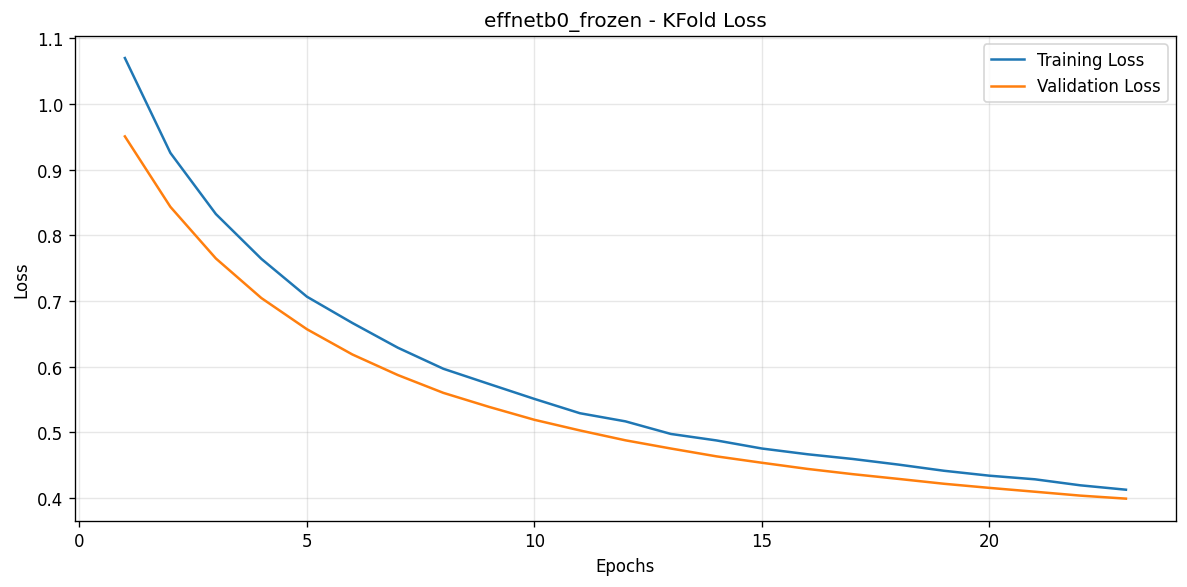

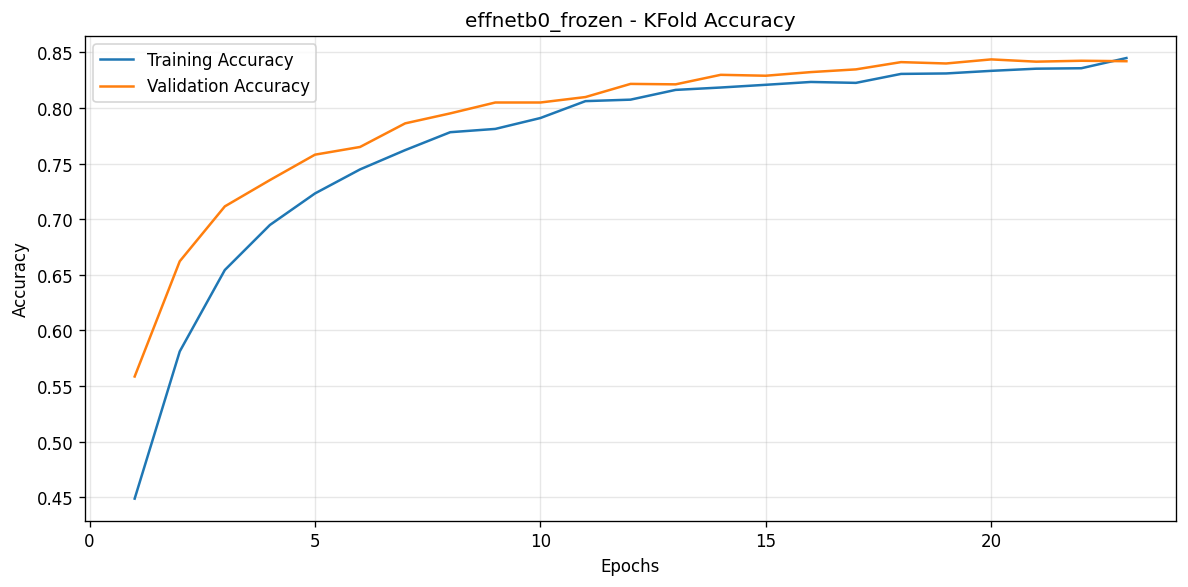

In [29]:
plot_kfold(
    effnet_base_histories,
    title_prefix=cfg_effnet_base["experiment_name"],
    save_paths=save_paths
)

In [30]:
with open(save_paths["kfold_metrics"], "w") as f:
    for row in effnet_base_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(effnet_base_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(effnet_base_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(effnet_base_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(effnet_base_losses):.4f}\n")

In [31]:
del effnet_base_metrics
del effnet_base_histories
gc.collect()

38635

In [32]:
tf.keras.backend.clear_session()

## Training + Evaluation

Preprocessing for: effnet
Using preprocessing: effnet
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 48s 422ms/step - accuracy: 0.4327 - loss: 1.0985 - val_accuracy: 0.5906 - val_loss: 0.9432
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5893 - loss: 0.9390 - val_accuracy: 0.7108 - val_loss: 0.8223
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6689 - loss: 0.8375 - val_accuracy: 0.7617 - val_loss: 0.7381
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7122 - loss: 0.7645 - val_accuracy: 0.7760 - val_loss: 0.6777
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7276 - loss: 0.7114 - val_accuracy: 0.7882 - val_loss: 0.6299
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7474 - loss: 0.6612 - val_accuracy: 0.7984 - val_loss: 0.5936
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7577 - loss: 0.6317 - val_accuracy: 0.7963 - val_loss: 0.5635
E

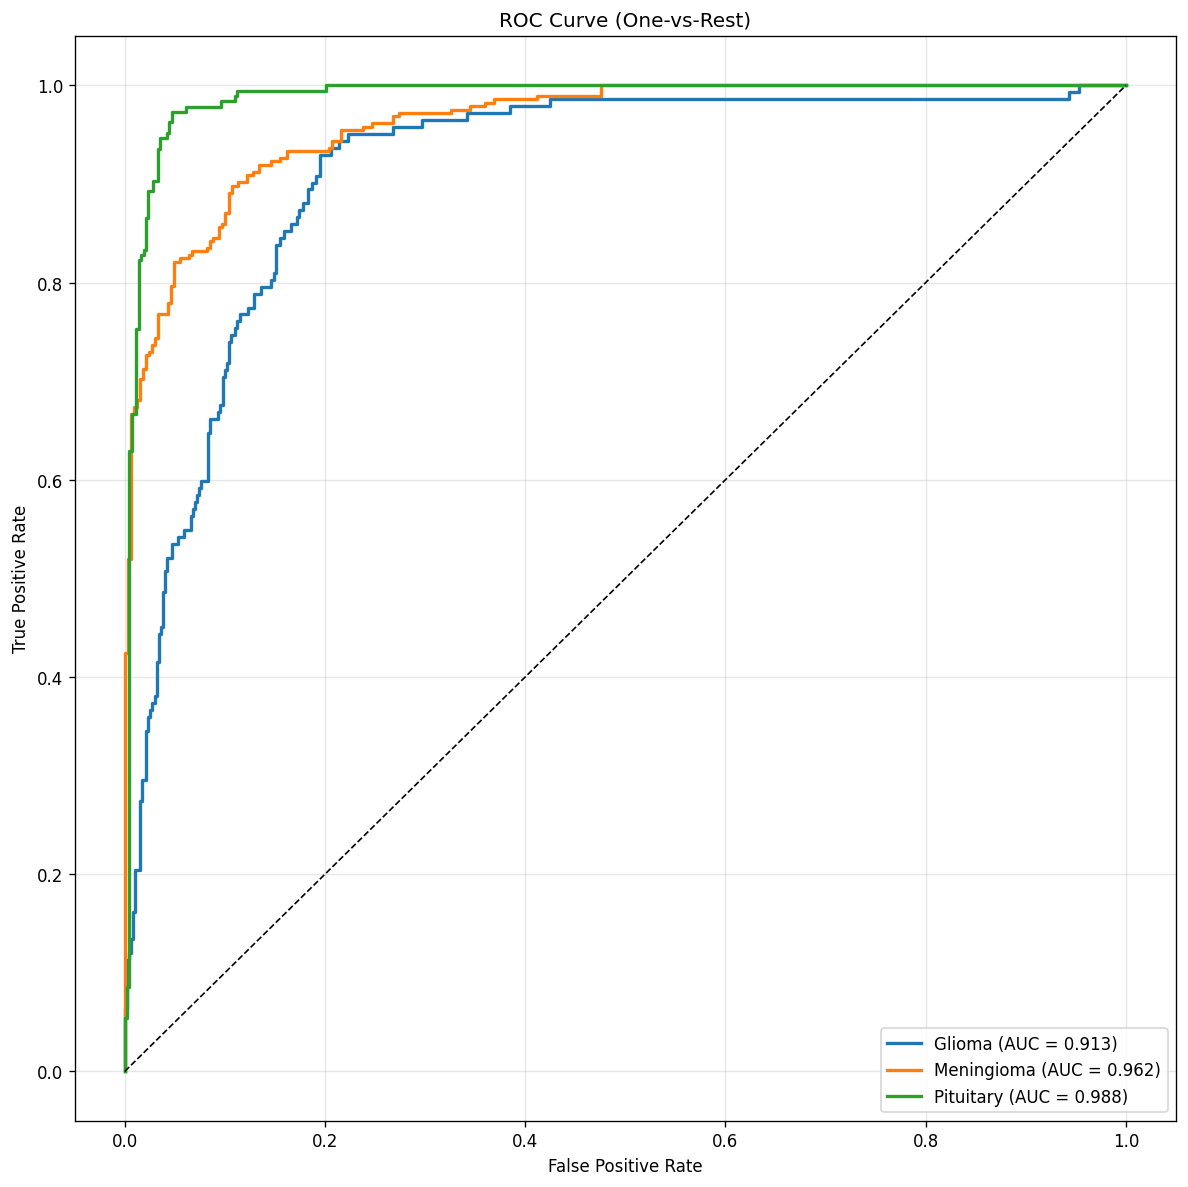


AUC per Class: 
Glioma: 0.9132
Meningioma: 0.9617
Pituitary: 0.9876
Macro AUC: 0.9542


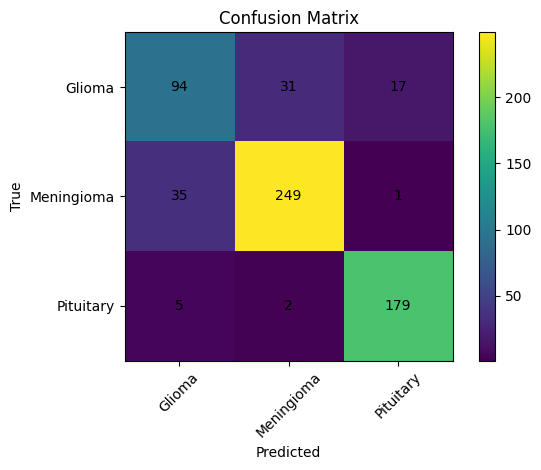

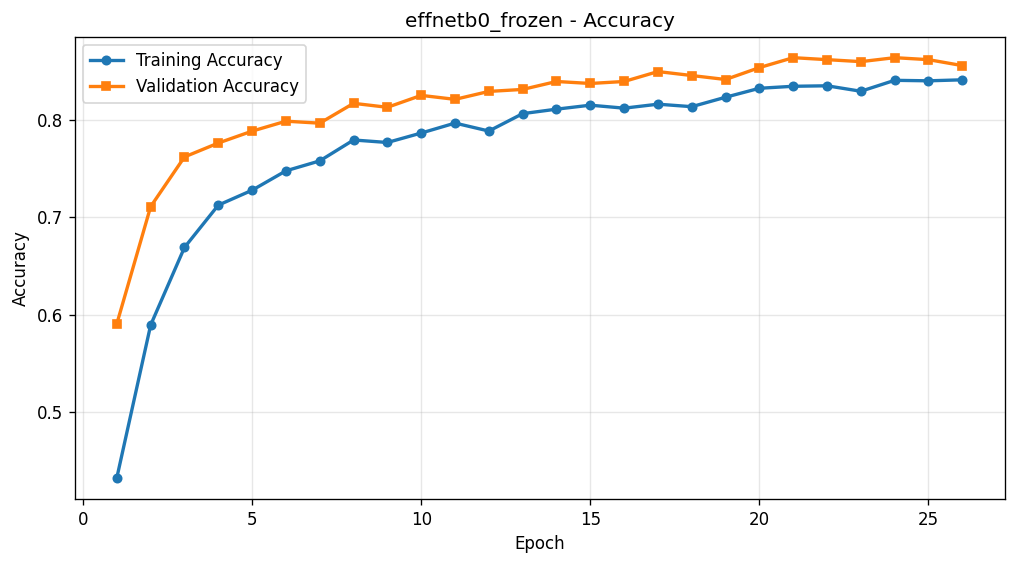

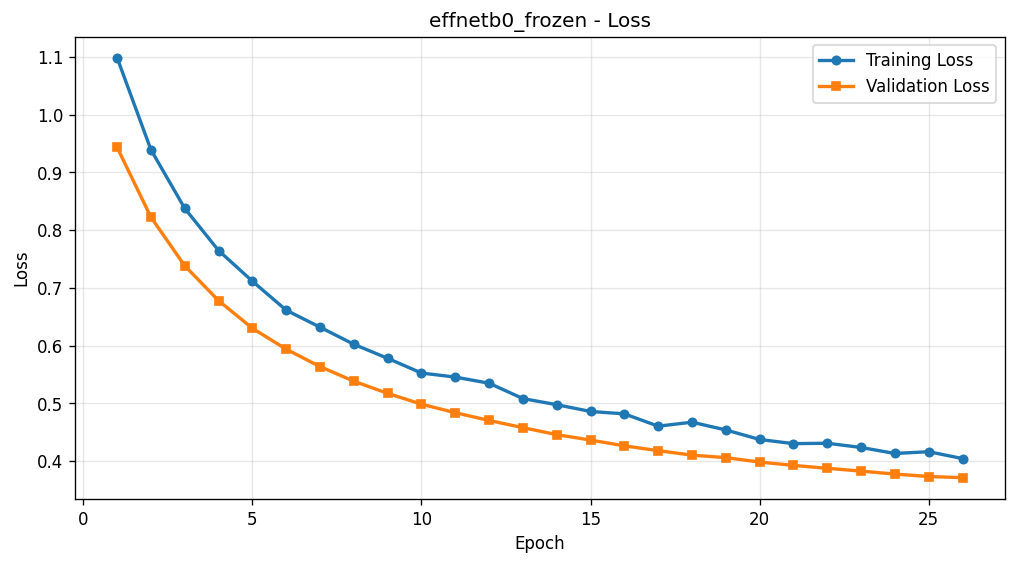

Loss:
  - loss [training dataset]: 0.404
  - loss [validation dataset]: 0.371

Accuracy:
  - accuracy [training dataset]: 84.08%
  - accuracy [validation dataset]: 85.54%


In [33]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, roc_raw_data_path = train_test(
    cfg=cfg_effnet_base,
    x_train_val_raw=x_train_val_raw,
    y_train_val_int=y_train_val_int,
    x_test_raw=x_test_raw,
    y_test_int=y_test_int,
    save_model=True
)

all_experiments["EfficientNetB0 Frozen"] = {
    "macro_auc":    macro_auc,
    "roc_raw_data": roc_raw_data_path + ".npz"
}

In [34]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_effnet_base, roc_raw_data_path, save_paths
gc.collect()

38842

In [35]:
tf.keras.backend.clear_session()

# EfficientNetB0 Frozen + Data Augmentation Model

In [36]:
cfg_effnet_aug = EXPERIMENTS["effnetb0_frozen_aug"]

## K-Fold(K = 5)

In [37]:
effnet_aug_metrics, effnet_aug_histories = kfold(
    x_raw=x_train_val_raw,
    y=y_train_val_int,
    cfg=cfg_effnet_aug,
    K=K,
    BATCH_SIZE=BATCH_SIZE,
    LR=LR,
    EPOCHS=EPOCHS
)


=== effnetb0_frozen_aug / Fold 1/5 ===
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 164ms/step - accuracy: 0.3811 - loss: 1.1303 - val_accuracy: 0.5458 - val_loss: 1.0160
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.5633 - loss: 0.9762 - val_accuracy: 0.6904 - val_loss: 0.8891
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.6423 - loss: 0.8727 - val_accuracy: 0.7230 - val_loss: 0.8023
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.6913 - loss: 0.7904 - val_accuracy: 0.7495 - val_loss: 0.7341
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.7112 - loss: 0.7381 - val_accuracy: 0.7617 - val_loss: 0.6853
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.7372 - loss: 0.6808 - val_accuracy: 0.7800 - val_loss: 0.6427
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.7434 - loss: 0.6534 - val_accuracy: 0.7963 - val_loss: 0.6100
Epoch 8/30


In [38]:
effnet_aug_accuracy = [m["val_acc"] for m in effnet_aug_metrics]
effnet_aug_losses = [m["val_loss"] for m in effnet_aug_metrics]

print("Fold Accuracies:", effnet_aug_accuracy)
print("Mean Accuracy :", np.mean(effnet_aug_accuracy))
print("Std Accuracy  :", np.std(effnet_aug_accuracy))
print("Mean Loss     :", np.mean(effnet_aug_losses))
print("Std Loss      :", np.std(effnet_aug_losses))

Fold Accuracies: [0.8533604741096497, 0.8428571224212646, 0.8795918226242065, 0.8163265585899353, 0.8571428656578064]
Mean Accuracy : 0.8498557686805726
Std Accuracy  : 0.0206048859516569
Mean Loss     : 0.38165201544761657
Std Loss      : 0.03250098589026948


In [39]:
save_paths = get_save_paths(cfg_effnet_aug["experiment_name"])

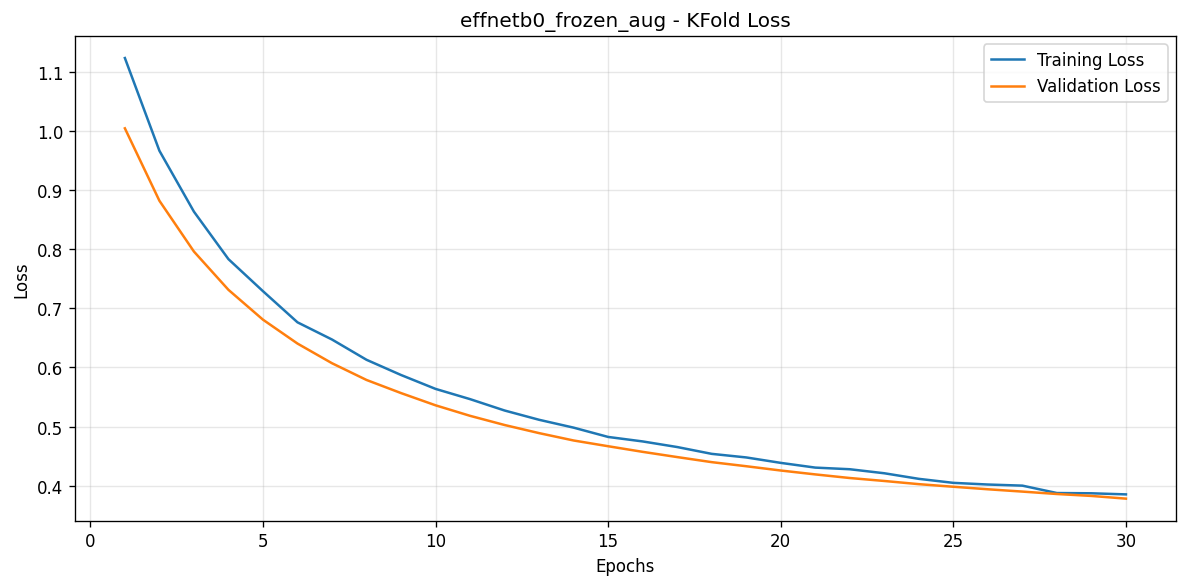

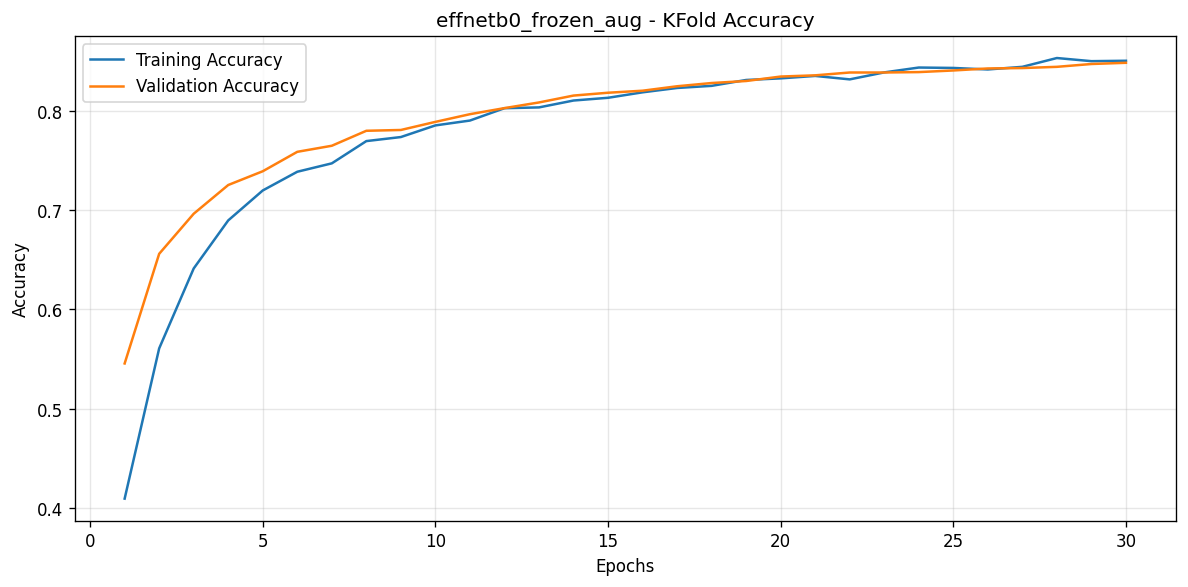

In [40]:
plot_kfold(
    effnet_aug_histories,
    title_prefix=cfg_effnet_aug["experiment_name"],
    save_paths=save_paths
)

In [41]:
with open(save_paths["kfold_metrics"], "w") as f:
    for row in effnet_aug_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(effnet_aug_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(effnet_aug_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(effnet_aug_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(effnet_aug_losses):.4f}\n")

In [42]:
del effnet_aug_metrics
del effnet_aug_histories
gc.collect()

39366

In [43]:
tf.keras.backend.clear_session()

## Training + Evaluation

Preprocessing for: effnet
Using preprocessing: effnet
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.4847 - loss: 1.0467 - val_accuracy: 0.6191 - val_loss: 0.9207
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.6082 - loss: 0.9143 - val_accuracy: 0.7006 - val_loss: 0.8185
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.6684 - loss: 0.8214 - val_accuracy: 0.7434 - val_loss: 0.7421
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.7082 - loss: 0.7554 - val_accuracy: 0.7576 - val_loss: 0.6847
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.7240 - loss: 0.7107 - val_accuracy: 0.7739 - val_loss: 0.6371
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.7449 - loss: 0.6624 - val_accuracy: 0.7882 - val_loss: 0.6002
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.7633 - loss: 0.6340 - val_accuracy: 0.8024 - val_loss: 0.5684


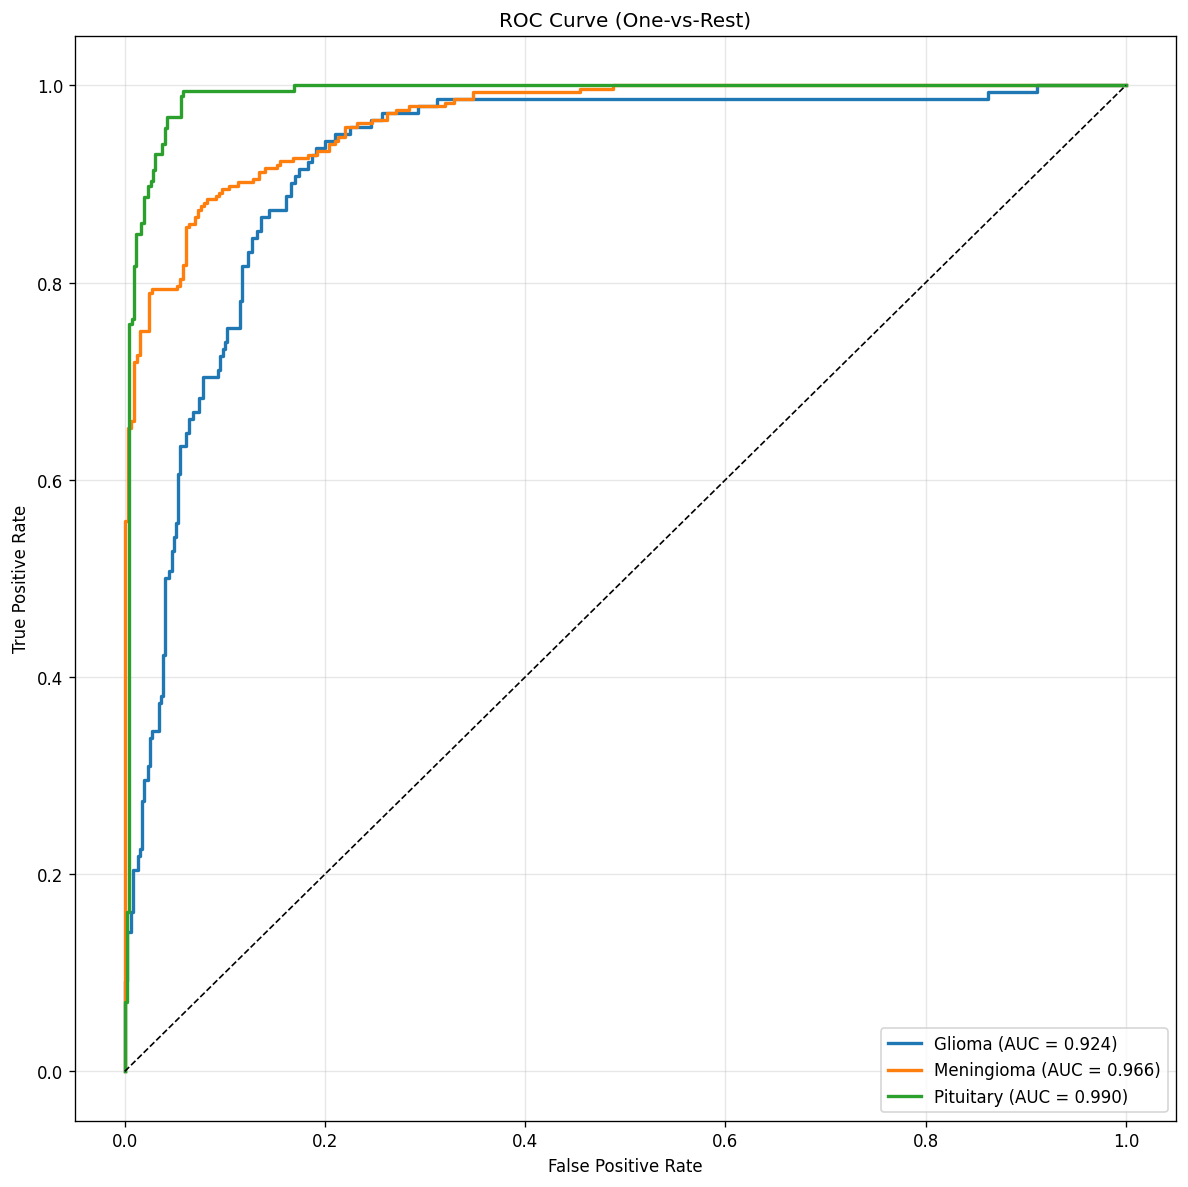


AUC per Class: 
Glioma: 0.9236
Meningioma: 0.9665
Pituitary: 0.9903
Macro AUC: 0.9601


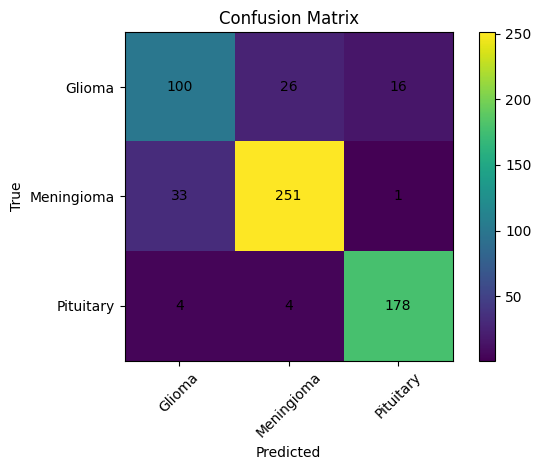

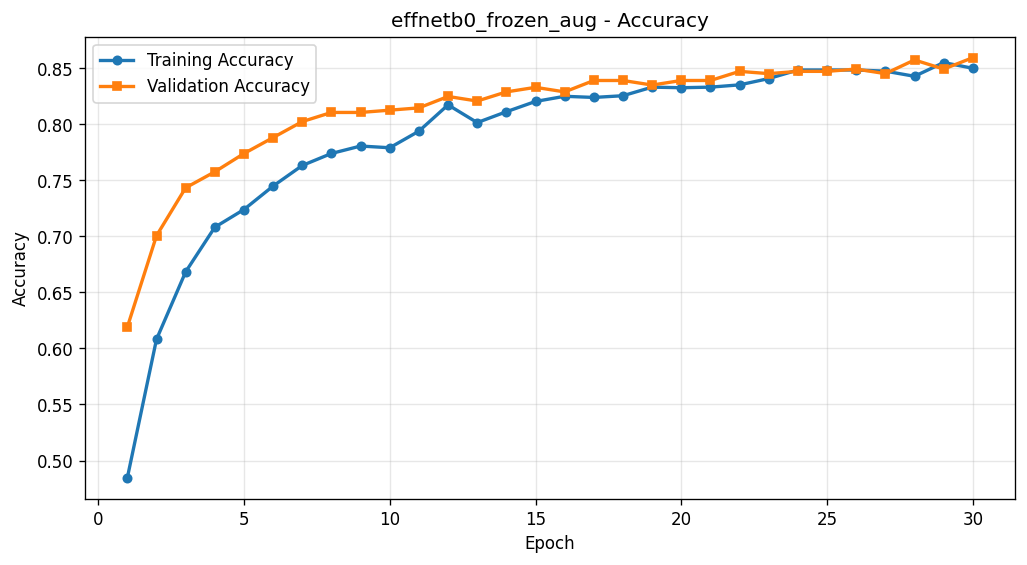

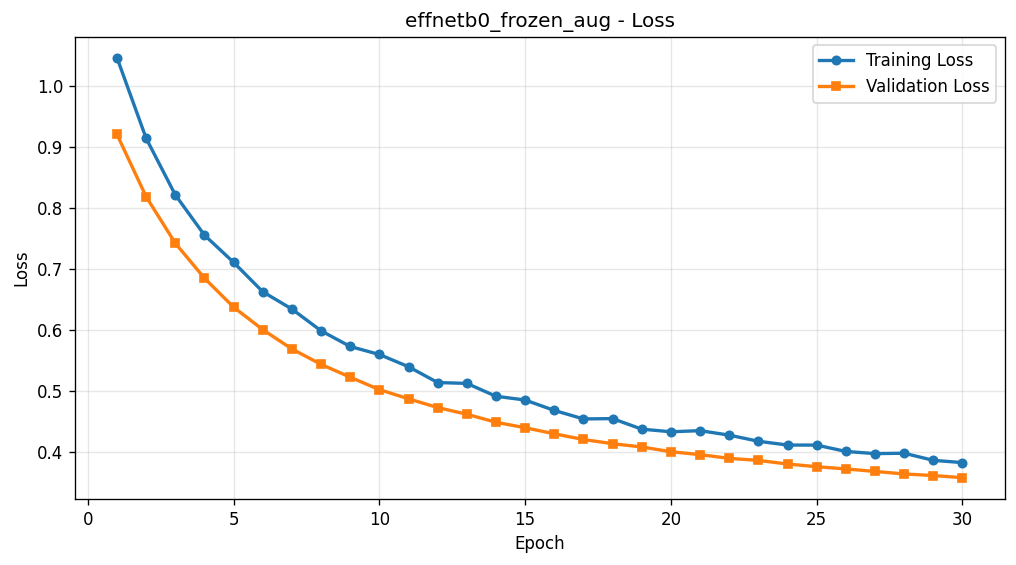

Loss:
  - loss [training dataset]: 0.382
  - loss [validation dataset]: 0.357

Accuracy:
  - accuracy [training dataset]: 85.00%
  - accuracy [validation dataset]: 85.95%


In [44]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, roc_raw_data_path = train_test(
    cfg=cfg_effnet_aug,
    x_train_val_raw=x_train_val_raw,
    y_train_val_int=y_train_val_int,
    x_test_raw=x_test_raw,
    y_test_int=y_test_int,
    save_model=True
)

all_experiments["EfficientNetB0 Frozen Aug"] = {
    "macro_auc":    macro_auc,
    "roc_raw_data": roc_raw_data_path + ".npz"
}

In [45]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_effnet_aug, roc_raw_data_path, save_paths
gc.collect()

32274

In [46]:
del x_train_val_raw, x_test_raw
gc.collect()

0

In [47]:
tf.keras.backend.clear_session()

# EfficientNetB0 Frozen vs EfficientNetB0 Frozen Aug

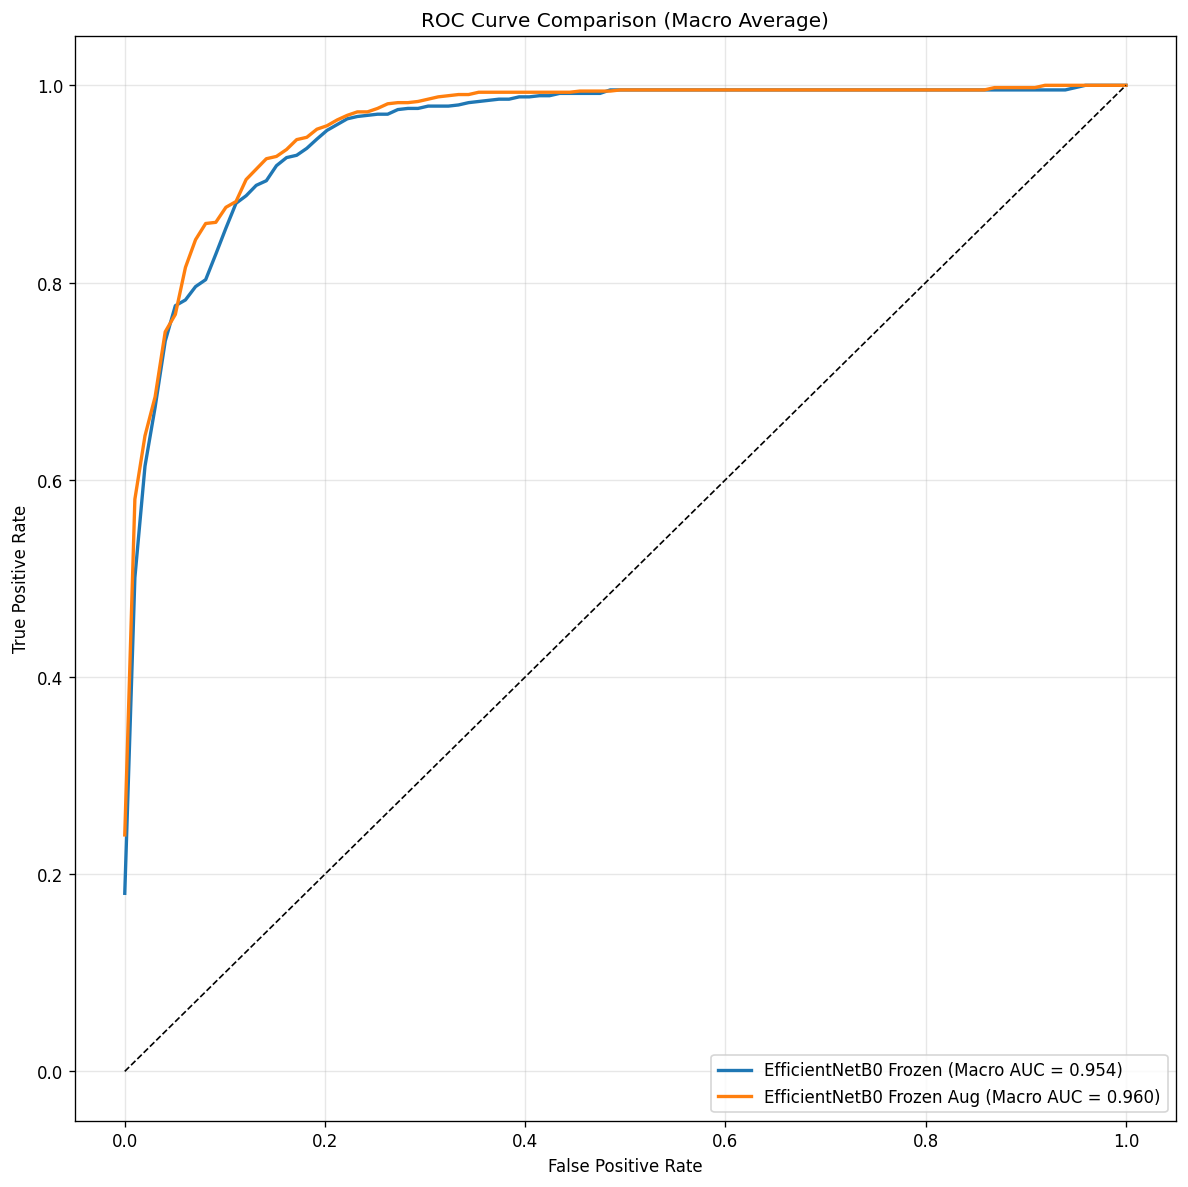

Best EffNetB0 experiment: EfficientNetB0 Frozen Aug (Macro AUC = 0.960)
Saved to: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 Model/effnet_experiments.pkl


In [48]:
plot_combined_roc(all_experiments, Class_Names, save_path=combined_roc_effnet_path)

best_name, best_data = max(all_experiments.items(), key=lambda x: x[1]["macro_auc"])
print(f"Best EffNetB0 experiment: {best_name} (Macro AUC = {best_data['macro_auc']:.3f})")

with open(effnet_experiments_path, "wb") as f:
    pickle.dump(all_experiments, f)

print(f"Saved to: {effnet_experiments_path}")